 Data cleaning + merge

In [2]:
import pandas as pd

fg = pd.read_csv('Dataset/fear_greed_index.csv')
trades = pd.read_csv('Dataset/historical_data.csv')

print(fg.shape)
print(trades.shape)

fg.head()

(2644, 4)
(211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
print(fg.dtypes)
print(trades.dtypes)

timestamp         int64
value             int64
classification      str
date                str
dtype: object
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object


In [5]:
print(fg.isnull().sum())
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [6]:
trades[['Timestamp IST', 'Timestamp']].head()

,Timestamp IST,Timestamp
0,02-12-2024 22:50,1.730000e+12
1,02-12-2024 22:50,1.730000e+12
2,02-12-2024 22:50,1.730000e+12
3,02-12-2024 22:50,1.730000e+12
4,02-12-2024 22:50,1.730000e+12


create a clean date column:


In [7]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.strftime('%Y-%m-%d')
trades[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,02-12-2024 22:50,2024-12-02
1,02-12-2024 22:50,2024-12-02
2,02-12-2024 22:50,2024-12-02
3,02-12-2024 22:50,2024-12-02
4,02-12-2024 22:50,2024-12-02


In [8]:
print("Trades date range:", trades['date'].min(), "to", trades['date'].max())
print("Sentiment date range:", fg['date'].min(), "to", fg['date'].max())

print("Unique trade dates:", trades['date'].nunique())
print("Unique sentiment dates:", fg['date'].nunique())

Trades date range: 2023-05-01 to 2025-05-01
Sentiment date range: 2018-02-01 to 2025-05-02
Unique trade dates: 480
Unique sentiment dates: 2644


In [9]:
merged = trades.merge(fg[['date', 'classification', 'value']], on='date', how='left')
print(merged['classification'].isnull().sum())  # should be 0
merged.head()

6


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [10]:
print(merged['classification'].isnull().sum()) 

6


In [11]:
print(merged[merged['classification'].isnull()]['date'].unique())

<StringArray>
['2024-10-26']
Length: 1, dtype: str


In [12]:
merged = merged.dropna(subset=['classification'])
print(merged.shape)

(211218, 19)


In [13]:
summary = merged.groupby('classification').agg(
    total_trades=('Closed PnL', 'count'),
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    win_rate=('Closed PnL', lambda x: (x > 0).sum() / (x != 0).sum() * 100),
    avg_size_usd=('Size USD', 'mean'),
    avg_fee=('Fee', 'mean'),
    long_ratio=('Direction', lambda x: (x.str.contains('Long', case=False, na=False)).sum() / len(x) * 100)
).round(2)

print(summary)

                total_trades  avg_pnl   total_pnl  win_rate  avg_size_usd  \
classification                                                              
Extreme Fear           21400    34.54   739110.25     76.22       5349.73   
Extreme Greed          39992    67.89  2715171.31     89.17       3112.25   
Fear                   61837    54.29  3357155.44     87.29       7816.11   
Greed                  50303    42.74  2150129.27     76.89       5736.88   
Neutral                37686    34.31  1292920.68     82.39       4782.73   

                avg_fee  long_ratio  
classification                       
Extreme Fear       1.12       61.95  
Extreme Greed      0.68       33.77  
Fear               1.50       56.79  
Greed              1.25       32.96  
Neutral            1.04       53.71  


### 1. Traders win more during Fear than during Greed
- **Fear**: 87.3% win rate
- **Greed**: 76.9% win rate
- **Extreme Greed**: 89.2% win rate (highest of all)
- **Extreme Fear**: 76.2% win rate (lowest, tied with Greed)

### 2. Traders go long more during Fear, and short more during Greed
- **Extreme Fear**: 62% of trades were long (buying)
- **Fear**: 57% long
- **Greed**: only 33% long
- **Extreme Greed**: only 34% long

## Statistical Significance Test

To confirm the difference in profit between Fear and Greed

In [14]:
from scipy import stats

fear_pnl = merged[merged['classification']=='Fear']['Closed PnL']
greed_pnl = merged[merged['classification']=='Greed']['Closed PnL']

stat, p = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print("p-value:", p)

p-value: 1.3045873858600704e-68


## Result

**p-value = 1.30 × 10⁻⁶⁸** (an extremely small number, far below 0.05)

This confirms the difference in profit between Fear and Greed periods is 
**statistically significant** — it is a real pattern in the data, not random chance.

**Conclusion:** Traders genuinely perform differently depending on market sentiment, 
and the contrarian pattern observed (better performance during Fear, betting against 
the crowd) is a reliable, confirmed finding — not a coincidence.

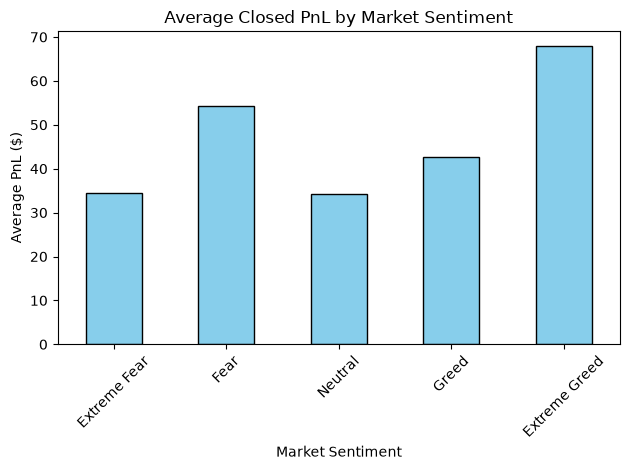

In [15]:
import matplotlib.pyplot as plt

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# Chart 1: Average PnL by sentiment
avg_pnl = merged.groupby('classification')['Closed PnL'].mean().reindex(order)
avg_pnl.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Closed PnL by Market Sentiment')
plt.ylabel('Average PnL ($)')
plt.xlabel('Market Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Dataset/avg_pnl_chart.png')
plt.show()

### Chart 1: Average Closed PnL by Market Sentiment

This chart shows average profit per trade across each sentiment category. 
Extreme Greed and Fear stand out with the highest average profits, while 
Extreme Fear and Neutral are the lowest. This confirms the pattern is not 
a simple straight line from "bad in fear" to "good in greed" — the 
relationship is more nuanced.

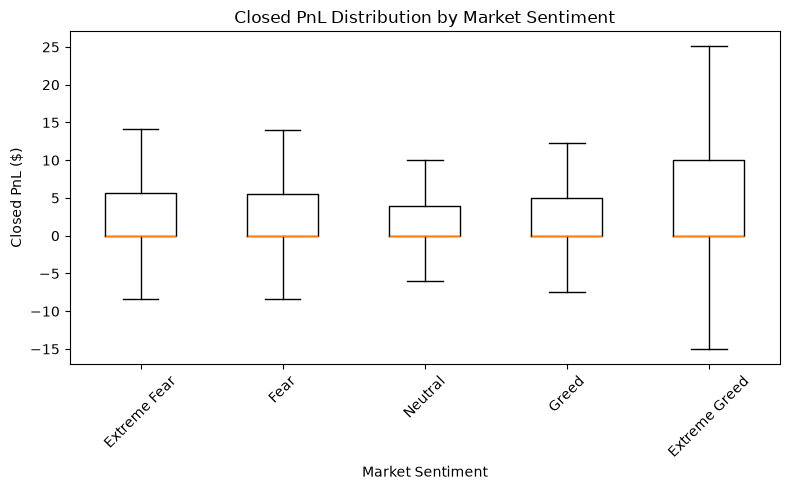

In [18]:
plt.figure(figsize=(8,5))
data_to_plot = [merged[merged['classification']==cat]['Closed PnL'] for cat in order]
plt.boxplot(data_to_plot, showfliers=False)
plt.xticks(ticks=range(1, len(order)+1), labels=order, rotation=45)
plt.title('Closed PnL Distribution by Market Sentiment')
plt.ylabel('Closed PnL ($)')
plt.xlabel('Market Sentiment')
plt.tight_layout()
plt.savefig('Dataset/pnl_boxplot.png')
plt.show()

### Chart 2: Closed PnL Distribution by Market Sentiment

This box plot shows not just average profit, but how much profits/losses vary 
in each sentiment regime. Extreme Greed shows the widest range of outcomes — 
both the highest gains and the largest losses — meaning it's the highest-risk, 
highest-reward regime. Neutral and Greed periods show tighter, more predictable 
outcomes. This suggests that while Extreme Greed has a high average profit 
(seen in Chart 1), it also carries more risk than the average alone reveals.